# Segmentation Clients — KMeans Clustering
---

## 1. Importation des librairies

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

## 2. Chargement des données

In [98]:
df = pd.read_csv('dataset/marketing_campaign_traited.csv', sep=',')
df.drop('Unnamed: 0',axis=1,inplace=True)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0


In [99]:
df.shape

(2211, 27)

## 3. Nettoyage préliminaire
L'EDA et le prétraitement ont déjà été réalisés dans le notebook précédent.  
On applique ici les étapes de nettoyage essentielles avant la segmentation.

In [100]:
# Suppression des valeurs manquantes résiduelles
df.dropna(inplace=True)

# Suppression des colonnes inutiles pour la segmentation
cols_to_drop = ['ID', 'Dt_Customer']
df_seg = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df_seg.shape

(2211, 25)

In [101]:
# Feature engineering
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
spend_cols = [c for c in spend_cols if c in df_seg.columns]
if spend_cols:
    df_seg['TotalSpend'] = df_seg[spend_cols].sum(axis=1)

cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
            'AcceptedCmp4', 'AcceptedCmp5']
cmp_cols = [c for c in cmp_cols if c in df_seg.columns]
if cmp_cols:
    df_seg['TotalCampaignsAccepted'] = df_seg[cmp_cols].sum(axis=1)

purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases',
                 'NumStorePurchases', 'NumDealsPurchases']
purchase_cols = [c for c in purchase_cols if c in df_seg.columns]
if purchase_cols:
    df_seg['TotalPurchases'] = df_seg[purchase_cols].sum(axis=1)

## 4. Encodage des variables qualitatives
KMeans ne peut travailler qu'avec des variables numériques.  
On encode `Education` et `Marital_Status` avec `get_dummies`.

In [102]:
cat_cols = df_seg.select_dtypes(include='object').columns.tolist()
cat_cols

['Education', 'Marital_Status']

In [103]:
# Encodage One-Hot avec drop_first pour éviter la multicolinéarité
df_encoded = pd.get_dummies(
    df_seg,
    columns=cat_cols,
    drop_first=True
)

# Conversion des booléens en int 
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f'Dimensions après encodage : {df_encoded.shape}')
df_encoded.head()

Dimensions après encodage : (2211, 34)


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,TotalCampaignsAccepted,TotalPurchases,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,1957,58138.0,0,0,58,635,88,546,172,88,...,0,25,0,1,0,0,0,1,0,0
1,1954,46344.0,1,1,38,11,1,6,2,1,...,0,6,0,1,0,0,0,1,0,0
2,1965,71613.0,0,0,26,426,49,127,111,21,...,0,21,0,1,0,0,0,0,1,0
3,1984,26646.0,1,0,26,11,4,20,10,3,...,0,8,0,1,0,0,0,0,1,0
4,1981,58293.0,1,0,94,173,43,118,46,27,...,0,19,0,0,0,1,1,0,0,0


## 5. Standardisation des features
La standardisation est indispensable pour KMeans car l'algorithme est basé sur des distances euclidiennes.  
Sans cette étape, une variable comme `Income` (en milliers) dominerait totalement les variables binaires comme `Kidhome`.

In [104]:
X = df_encoded.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Moyenne (proche de 0)  : {X_scaled.mean(axis=0).round(3)[:5]}')
print(f'Ecart-type (proche de 1) : {X_scaled.std(axis=0).round(3)[:5]}')

Moyenne (proche de 0)  : [-0. -0.  0. -0. -0.]
Ecart-type (proche de 1) : [1. 1. 1. 1. 1.]


## 6. Détermination du nombre optimal de clusters
### 6.1 Méthode Elbow (Inertie)

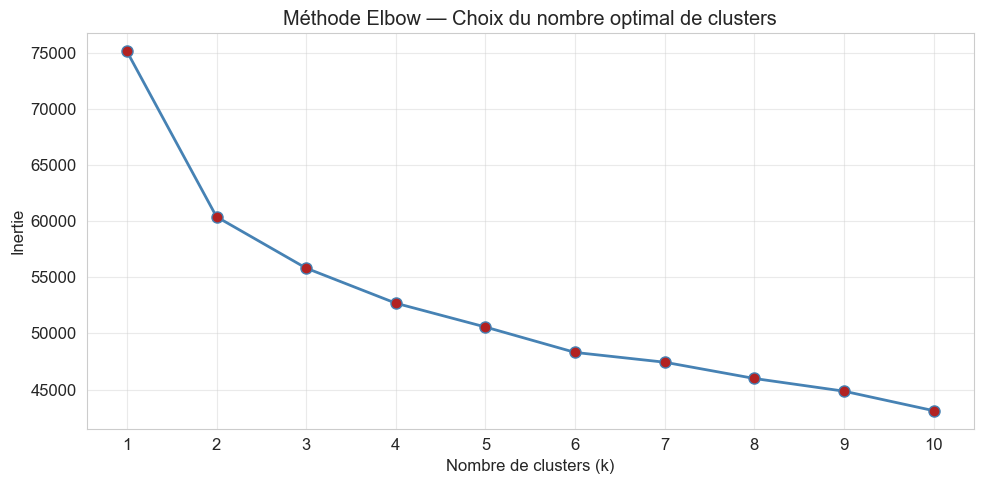

In [105]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linewidth=2,
         color='steelblue', markersize=8, markerfacecolor='firebrick')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode Elbow — Choix du nombre optimal de clusters')
plt.xticks(K_range)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Selon la méthode de coud, le meillieur nombre de cluster est 2.

### 6.2 Méthode du Silhouette Score
Le Silhouette Score mesure la qualité de la segmentation.  
Il varie entre -1 et 1 : plus il est proche de 1, meilleure est la séparation des clusters.

k=2  |  Silhouette Score : 0.2119
k=3  |  Silhouette Score : 0.1840
k=4  |  Silhouette Score : 0.1442
k=5  |  Silhouette Score : 0.1501
k=6  |  Silhouette Score : 0.1561
k=7  |  Silhouette Score : 0.0884
k=8  |  Silhouette Score : 0.1104
k=9  |  Silhouette Score : 0.1059
k=10  |  Silhouette Score : 0.1231


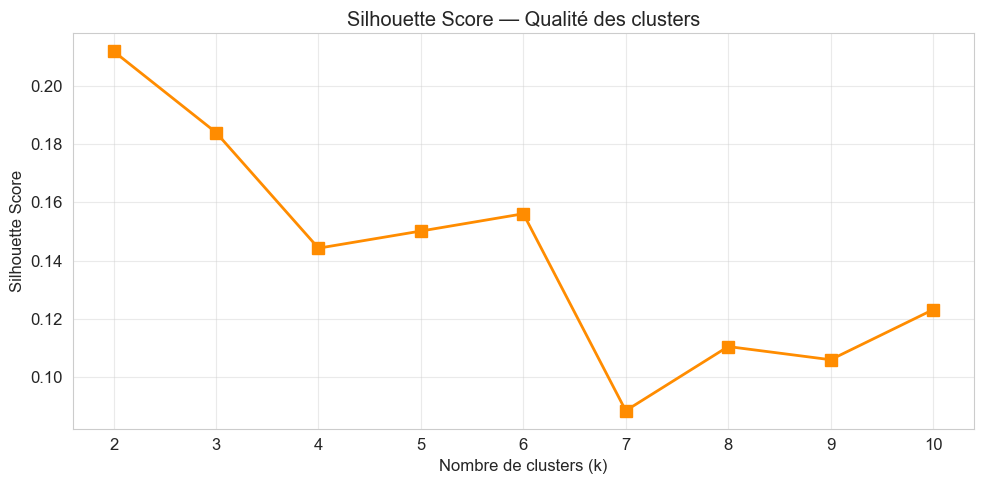


Nombre optimal de clusters selon le Silhouette Score : k = 2


In [106]:
silhouette_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f'k={k}  |  Silhouette Score : {score:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(K_range_sil, silhouette_scores, marker='s', linewidth=2,
         color='darkorange', markersize=8)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Qualité des clusters')
plt.xticks(K_range_sil)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

best_k = K_range_sil[np.argmax(silhouette_scores)]
print(f'\nNombre optimal de clusters selon le Silhouette Score : k = {best_k}')

### 6.3 Conclusion sur le choix de k

In [118]:
N_CLUSTERS = 5  # choisir 2 est très simple pour notre objectif
print(f'Nombre de clusters retenu : {N_CLUSTERS}')

Nombre de clusters retenu : 5


## 7. Application du modèle KMeans

In [119]:
kmeans_final = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10,
    max_iter=1000
)

clusters = kmeans_final.fit_predict(X_scaled)

In [124]:
help(Pipeline)

Help on class Pipeline in module sklearn.pipeline:

class Pipeline(sklearn.utils.metaestimators._BaseComposition)
 |  Pipeline(steps, *, transform_input=None, memory=None, verbose=False)
 |
 |  A sequence of data transformers with an optional final predictor.
 |
 |  `Pipeline` allows you to sequentially apply a list of transformers to
 |  preprocess the data and, if desired, conclude the sequence with a final
 |  :term:`predictor` for predictive modeling.
 |
 |  Intermediate steps of the pipeline must be transformers, that is, they
 |  must implement `fit` and `transform` methods.
 |  The final :term:`estimator` only needs to implement `fit`.
 |  The transformers in the pipeline can be cached using ``memory`` argument.
 |
 |  The purpose of the pipeline is to assemble several steps that can be
 |  cross-validated together while setting different parameters. For this, it
 |  enables setting parameters of the various steps using their names and the
 |  parameter name separated by a `'__'

In [120]:
X_scaled.shape

(2211, 34)

Distribution des clusters :
Cluster
0     424
1    1024
2     161
3     572
4      30
Name: count, dtype: int64


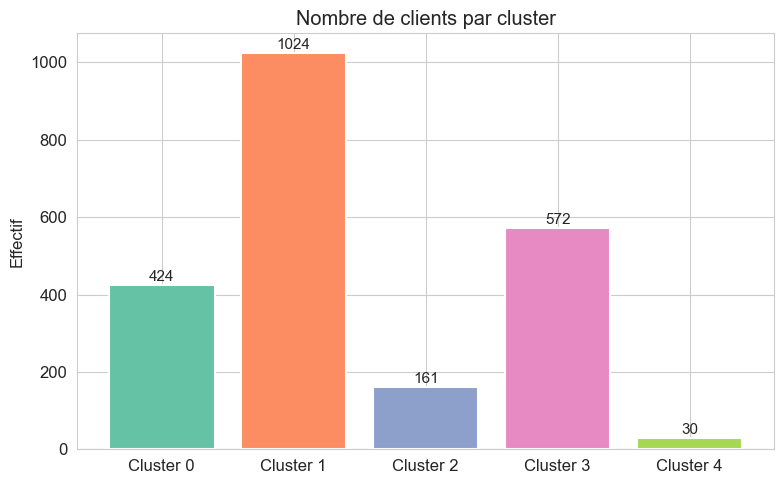

In [121]:
df['Cluster'] = clusters

# Distribution des clusters
print('Distribution des clusters :')
print(df['Cluster'].value_counts().sort_index())

plt.figure(figsize=(8, 5))
counts = df['Cluster'].value_counts().sort_index()
bars = plt.bar(
    [f'Cluster {i}' for i in counts.index],
    counts.values,
    color=sns.color_palette('Set2', N_CLUSTERS),
    edgecolor='white',
    linewidth=1.5
)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', fontsize=11)
plt.title('Nombre de clients par cluster')
plt.ylabel('Effectif')
plt.tight_layout()
plt.show()

## 8. Analyse et profilage des clusters
### 8.1 Statistiques descriptives par cluster

In [122]:
# Variables clés pour l'interprétation marketing
key_vars = [
    'Income', 'Kidhome', 'Teenhome',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'Recency',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5', 'Cluster'
]

# Garder seulement les colonnes présentes dans le dataframe
key_vars = [v for v in key_vars if v in df.columns]

profile = df[key_vars].groupby('Cluster').mean().round(2)
print('Profil moyen par cluster :')
profile

Profil moyen par cluster :


,Income,Kidhome,Teenhome,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Recency,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
Cluster,,,,,,,,,,,,,,,,,,,,
0,73034.34,0.05,0.24,500.46,73.01,432.76,106.04,71.37,76.76,1.53,5.13,5.89,8.42,2.95,50.25,0.08,0.0,0.05,0.02,0.00
1,34840.10,0.78,0.44,40.68,5.05,22.97,7.50,5.14,15.58,2.02,2.09,0.55,3.21,6.44,49.14,0.00,0.0,0.07,0.01,0.00
2,82294.83,0.06,0.12,856.20,58.60,497.16,84.08,68.70,78.22,1.04,5.55,6.04,8.17,2.90,47.66,0.46,0.0,0.16,0.33,0.88
3,57426.07,0.25,0.92,447.65,20.91,130.70,27.34,21.55,59.15,3.83,6.42,2.99,7.71,5.76,48.45,0.03,0.0,0.06,0.12,0.00
4,71054.83,0.07,0.43,898.67,22.97,250.30,38.73,30.60,66.40,1.70,4.90,5.17,8.17,5.17,48.67,0.43,1.0,0.23,0.73,0.57


### 8.2 Heatmap des profils moyens

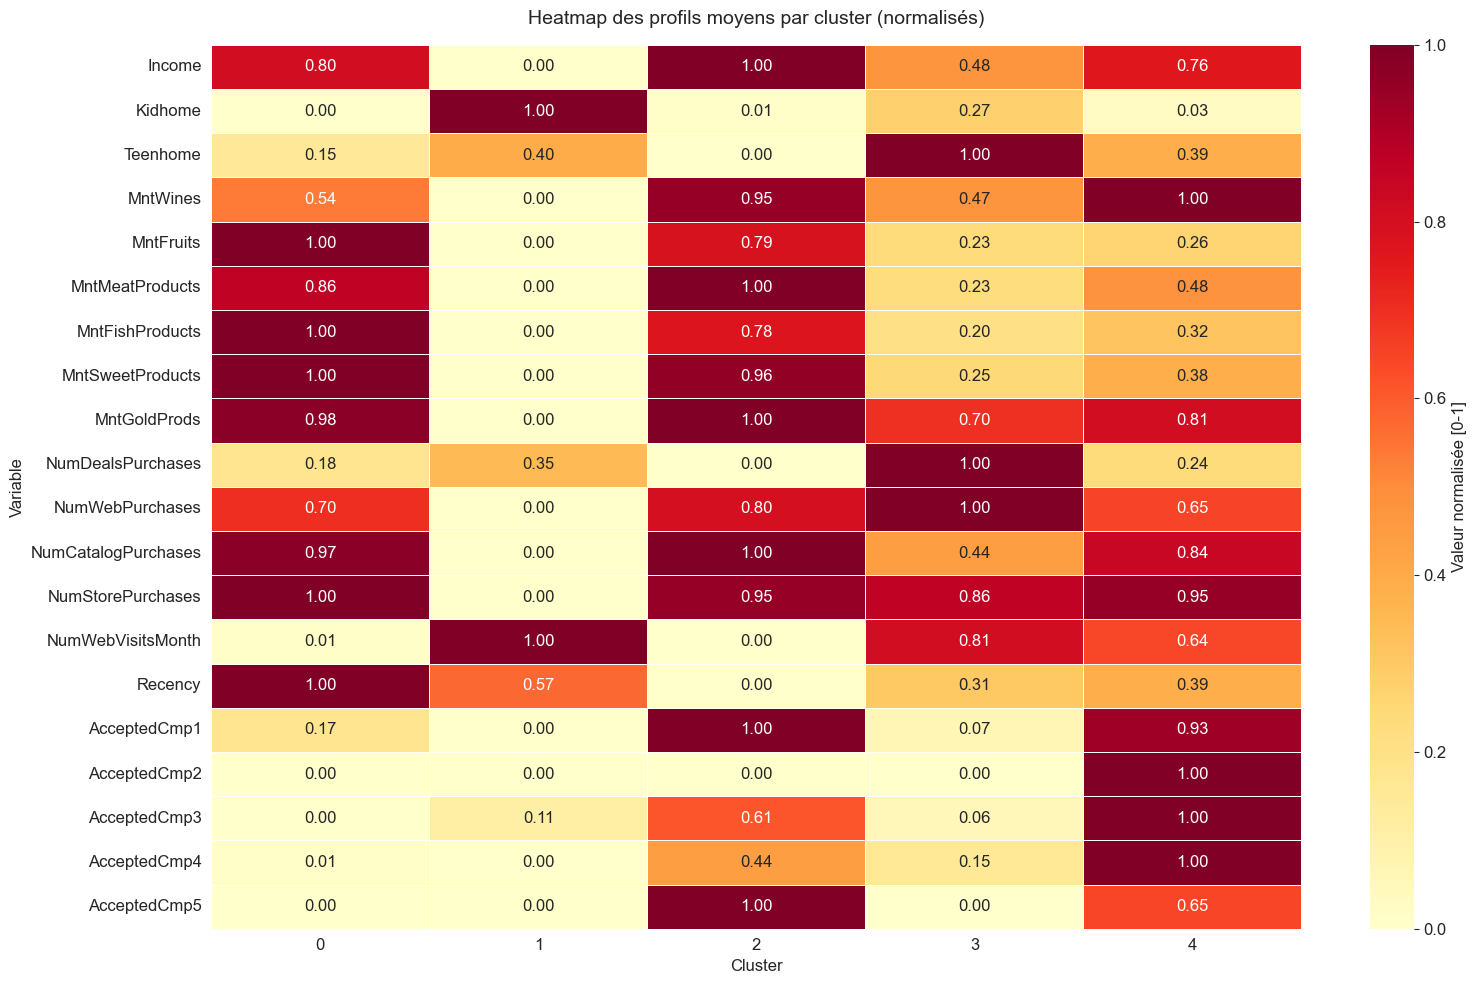

In [123]:
# Normalisation pour comparaison visuelle
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

plt.figure(figsize=(16, 10))
sns.heatmap(
    profile_norm.T,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Valeur normalisée [0-1]'}
)
plt.title('Heatmap des profils moyens par cluster (normalisés)', fontsize=14, pad=15)
plt.xlabel('Cluster')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

### 8.3 Boxplots des variables clés par cluster

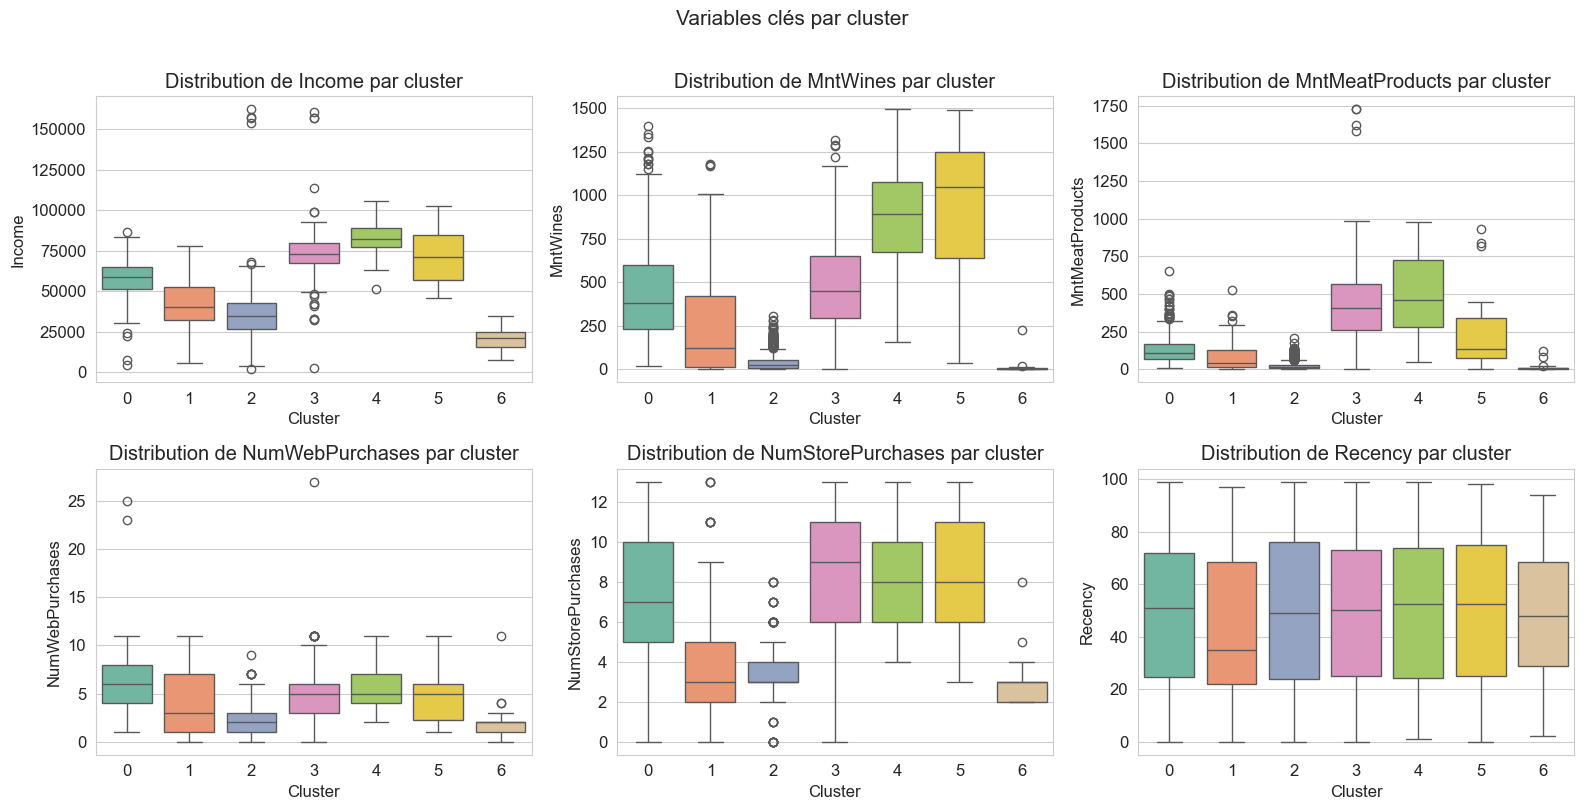

In [87]:
plot_vars = ['Income', 'MntWines', 'MntMeatProducts',
             'NumWebPurchases', 'NumStorePurchases', 'Recency']
plot_vars = [v for v in plot_vars if v in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(plot_vars) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

palette = sns.color_palette('Set2', N_CLUSTERS)

for i, var in enumerate(plot_vars):
    sns.boxplot(
        data=df, x='Cluster', y=var,
        palette=palette, ax=axes[i]
    )
    axes[i].set_title(f'Distribution de {var} par cluster')
    axes[i].set_xlabel('Cluster')

# Masquer les axes vides
for j in range(len(plot_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables clés par cluster', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 9. Visualisation PCA — Clusters en 2D
La PCA (Analyse en Composantes Principales) réduit la dimensionnalité pour permettre une visualisation 2D des clusters.

In [88]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

variance_explained = pca.explained_variance_ratio_
print(f'Variance expliquée — PC1 : {variance_explained[0]:.2%}')
print(f'Variance expliquée — PC2 : {variance_explained[1]:.2%}')
print(f'Variance totale expliquée : {sum(variance_explained):.2%}')

Variance expliquée — PC1 : 21.81%
Variance expliquée — PC2 : 7.07%
Variance totale expliquée : 28.87%


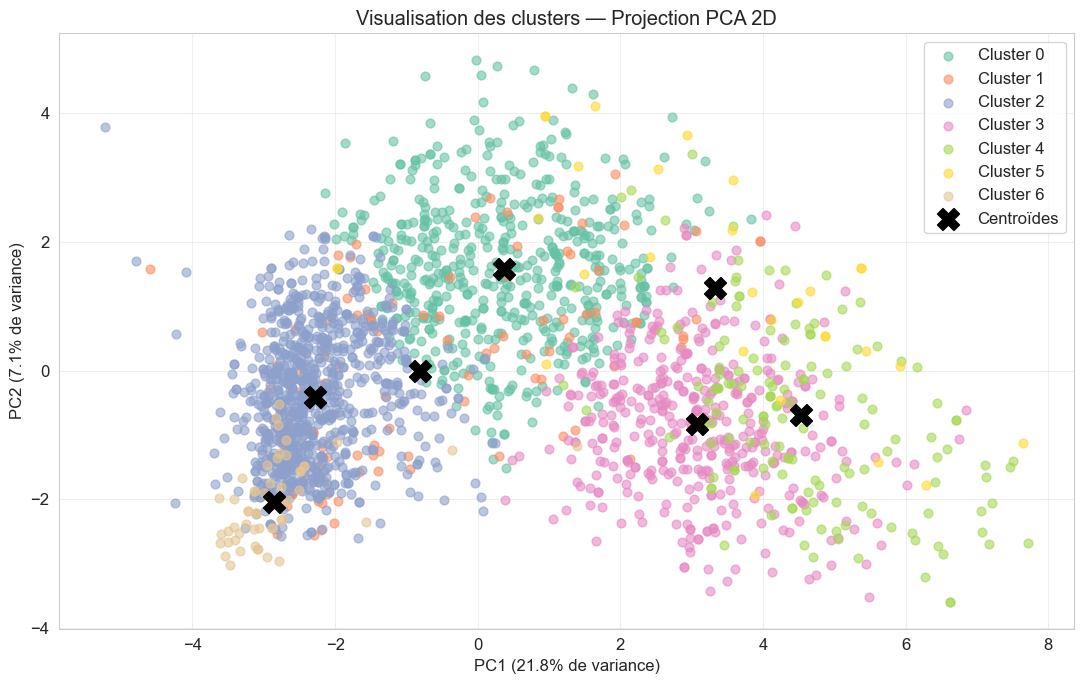

In [89]:
pca_df = pd.DataFrame({
    'PC1'    : X_pca[:, 0],
    'PC2'    : X_pca[:, 1],
    'Cluster': clusters
})

# Centres des clusters en espace PCA
centers_pca = pca.transform(kmeans_final.cluster_centers_)

plt.figure(figsize=(11, 7))
palette = sns.color_palette('Set2', N_CLUSTERS)

for k in range(N_CLUSTERS):
    mask = pca_df['Cluster'] == k
    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        s=40, alpha=0.6,
        color=palette[k],
        label=f'Cluster {k}'
    )

# Affichage des centres
plt.scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    s=250, marker='X', c='black',
    zorder=5, label='Centroïdes'
)

plt.xlabel(f'PC1 ({variance_explained[0]:.1%} de variance)')
plt.ylabel(f'PC2 ({variance_explained[1]:.1%} de variance)')
plt.title('Visualisation des clusters — Projection PCA 2D')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Analyse Silhouette par cluster

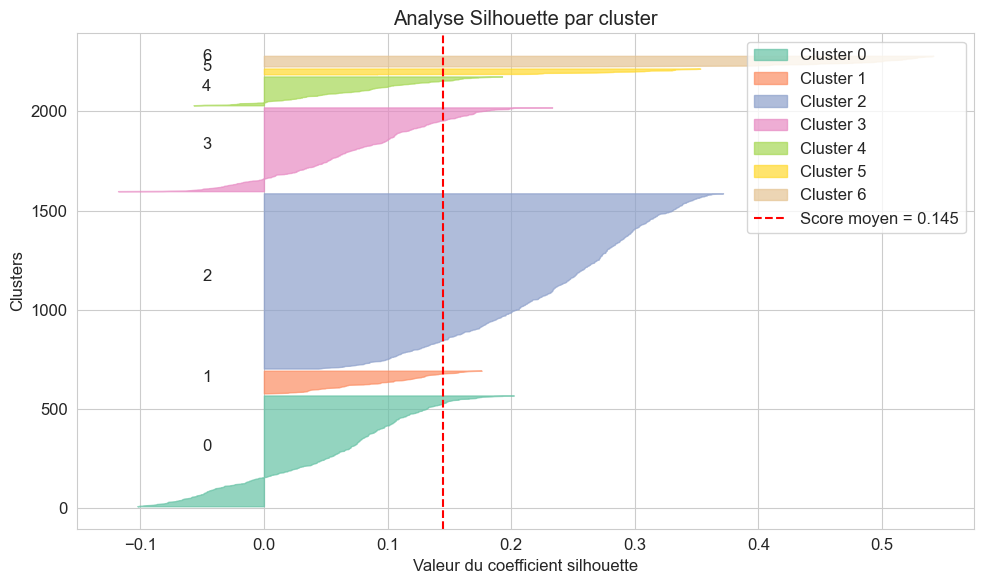


Silhouette Score global : 0.1449


In [90]:
silhouette_vals = silhouette_samples(X_scaled, clusters)
avg_score = silhouette_score(X_scaled, clusters)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
palette = sns.color_palette('Set2', N_CLUSTERS)

for k in range(N_CLUSTERS):
    cluster_sil_vals = np.sort(silhouette_vals[clusters == k])
    size_k = cluster_sil_vals.shape[0]
    y_upper = y_lower + size_k

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cluster_sil_vals,
        alpha=0.7,
        color=palette[k],
        label=f'Cluster {k}'
    )
    ax.text(-0.05, y_lower + 0.5 * size_k, str(k))
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=1.5,
           label=f'Score moyen = {avg_score:.3f}')
ax.set_xlabel('Valeur du coefficient silhouette')
ax.set_ylabel('Clusters')
ax.set_title('Analyse Silhouette par cluster')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f'\nSilhouette Score global : {avg_score:.4f}')

## 11. Interprétation marketing des clusters
Sur la base des statistiques descriptives calculées à l'étape 8, on attribue un profil business à chaque cluster.

In [91]:
# cluster_labels = {
#     0: 'Clients Premium',
#     1: 'Clients à faibles dépenses',
#     2: 'Clients digitaux actifs',
#     3: 'Clients familles / fidèles'
# }

cluster_labels = {
    0: 0,
    1: 1,
    2: 2,
    3: 3,
    4:4,
    5:5,
    6:6
}

# Ajuster le dictionnaire selon N_CLUSTERS
cluster_labels = {k: v for k, v in cluster_labels.items() if k < N_CLUSTERS}

interpretation = pd.DataFrame({
    'Cluster'     : list(cluster_labels.keys()),
    'Profil'      : list(cluster_labels.values()),
    'Effectif'    : [df[df['Cluster'] == k].shape[0] for k in cluster_labels.keys()],
    'Part (%)'    : [
        round(df[df['Cluster'] == k].shape[0] / len(df) * 100, 1)
        for k in cluster_labels.keys()
    ]
})

print('Tableau de synthèse marketing :')
print(interpretation.to_string(index=False))

Tableau de synthèse marketing :
 Cluster  Profil  Effectif  Part (%)
       0       0       559      25.3
       1       1       115       5.2
       2       2       884      40.0
       3       3       423      19.1
       4       4       146       6.6
       5       5        30       1.4
       6       6        54       2.4


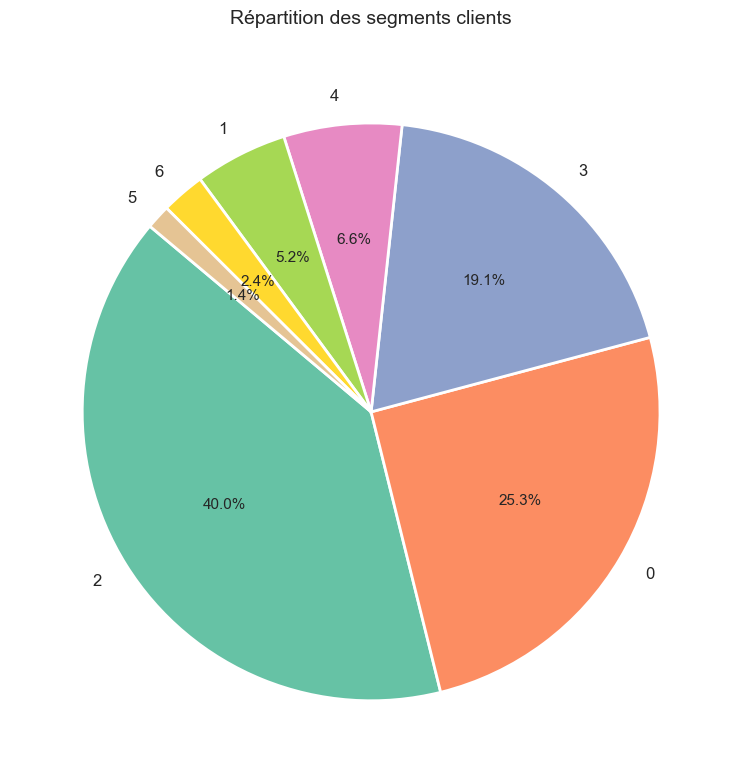

In [92]:
# Ajout du label dans le dataframe
df['Cluster_Label'] = df['Cluster'].map(cluster_labels)

# Visualisation camembert de la répartition
fig, ax = plt.subplots(figsize=(8, 8))
counts = df['Cluster_Label'].value_counts()

wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', N_CLUSTERS),
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for autotext in autotexts:
    autotext.set_fontsize(11)

ax.set_title('Répartition des segments clients', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 12. Export des résultats

In [70]:
# Export du dataset enrichi avec les clusters
df_export = df.copy()
df_export.drop('Cluster_Label',axis=1,inplace=True)
df_export.to_csv('dataset/clients_segmentes.csv', index=False)

# # Export du profil moyen par cluster
# profile.to_csv('profil_clusters.csv')
# print('Profil moyen par cluster exporté : profil_clusters.csv')

In [71]:
joblib.dump(kmeans_final,"models/seg_model.pkl")

['models/seg_model.pkl']